In [1]:
import os
import sys
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

# Add project root to python path
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# Import from our custom modules
from src.config import TRAIN_PATH, TEST_PATH
from src.dataset import get_data_loaders

# Load the data pipelines
train_ds, val_ds, test_ds = get_data_loaders()


Initializing Data Pipelines...
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.


In [3]:
%pip install -r ../requirements.txt

  Using cached kagglehub-1.0.2-py3-none-any.whl.metadata (40 kB)
  Using cached tensorflow-2.21.0-cp310-cp310-win_amd64.whl.metadata (4.5 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached notebook-7.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached kagglesdk-0.1.28-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached wrapt-2.2.2-cp310-cp310-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.81.1-

In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import sys

# Add the project root to the path so we can import from src
sys.path.append('..')
from src.config import TRAIN_PATH, TEST_PATH


In [ ]:
# =====================================================================
# SETUP CELL (Run this first!)
# =====================================================================
import os
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 1. Fix the import path so Python can see your 'src' folder
root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

# 2. Import your configured paths
from src.config import TRAIN_PATH, TEST_PATH

print("Paths successfully initialized!")
print(f"Checking Train Path: {TRAIN_PATH}")
print(f"Checking Test Path:  {TEST_PATH}")

Detected 6 classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

--- Class Counts Table ---
           Train  Test
buildings   2191   437
forest      2271   474
glacier     2404   553
mountain    2512   525
sea         2274   510
street      2382   501
--------------------------


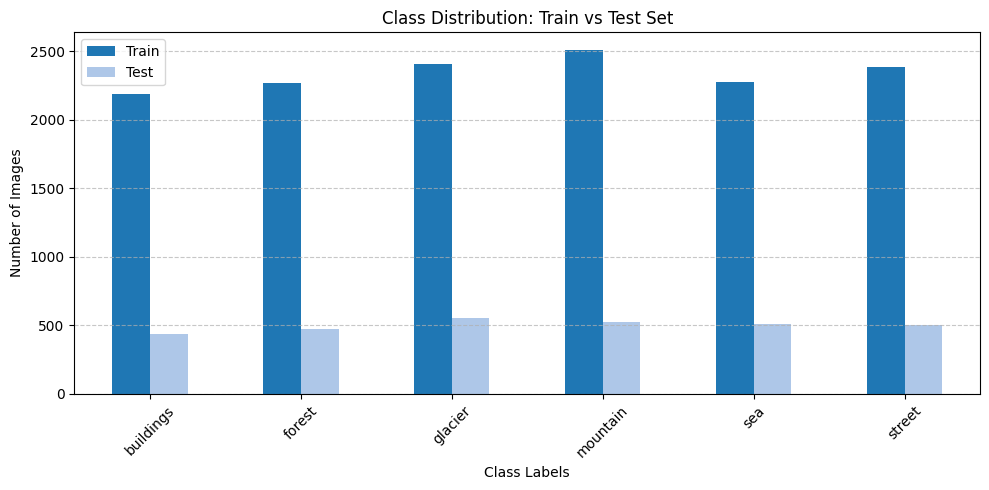

In [6]:
# =====================================================================
# ANALYSIS CELL 
# =====================================================================
# Class Distribution Analysis
classes = sorted([f for f in os.listdir(TRAIN_PATH) if not f.startswith('.')])
print(f"Detected {len(classes)} classes: {classes}\n")

train_counts = {}
test_counts = {}

for c in classes:
    # Use os.path.join instead of the / operator
    train_counts[c] = len(os.listdir(os.path.join(TRAIN_PATH, c)))
    test_counts[c] = len(os.listdir(os.path.join(TEST_PATH, c)))

df_counts = pd.DataFrame({"Train": train_counts, "Test": test_counts})
print("--- Class Counts Table ---")
print(df_counts)
print("-" * 26)

# Visualizing distribution
df_counts.plot(kind="bar", figsize=(10, 5), color=['#1f77b4', '#aec7e8'])
plt.title("Class Distribution: Train vs Test Set")
plt.ylabel("Number of Images")
plt.xlabel("Class Labels")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Prevents labels from getting cut off
plt.show()


In [10]:
from PIL import Image

# Cell 3: Image Property Analysis
sizes = []
modes = []  # To confirm RGB vs Grayscale
corrupt_files = []

# Sample a subset to keep execution lightning fast, or scan all to be thorough
for c in classes:
    # Use os.path.join here
    class_dir = os.path.join(TRAIN_PATH, c)
    for img_name in os.listdir(class_dir)[:50]: # checking first 50 of each class
        # And use os.path.join here as well
        img_path = os.path.join(class_dir, img_name)
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)
                modes.append(img.mode)
        except Exception as e:
            corrupt_files.append((img_path, str(e)))

unique_sizes = set(sizes)
unique_modes = set(modes)

print(f"Unique dimensions found in sample: {unique_sizes}")
print(f"Unique image color modes found: {unique_modes} (RGB means 3 channels)")
print(f"Corrupt files found: {len(corrupt_files)}")
if corrupt_files:
    print(corrupt_files)


Unique dimensions found in sample: {(150, 113), (150, 110), (150, 150)}
Unique image color modes found: {'RGB'} (RGB means 3 channels)
Corrupt files found: 0
